In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


import classification_rf

from importlib import reload
reload(classification_rf)

from classification_rf import RandomForestClassifier621

np.random.seed(24)

In [ ]:
def generate_study(features, n, study_label, similarity, intercept_sd):
    X = np.random.normal(loc = 0, scale = 1, size = (n,features)) #Base random inputs

    base = np.arange(features, dtype=float)
    noise = np.random.normal(loc=0, scale=np.std(base), size=features) #inter study weights will vary by this noise parameter controlled by tau
    base  /= np.linalg.norm(base)
    noise /= np.linalg.norm(noise)

    b = similarity * base + (1-similarity)*noise #At similarity 0,1 we get noise and unison.

    weighted_X = np.dot(X,b)
    
    intercept = np.random.normal(0, intercept_sd)

    pX = np.exp(weighted_X+intercept)/(1+np.exp(weighted_X+intercept)) # interval mapping (-inf,inf) to (0,1)

    y = np.random.binomial(n = 1, p = pX) #Random 0 or 1 with probability pX
    
    #print(f"norm of b: {np.linalg.norm(b):.4f}")
    #print(f"X shape: {X.shape}")
    print(f"Study {study_label}: intercept={intercept:.2f}, base_rate={y.mean():.2f}")
    print(f"X @ b range: {(X @ b).min():.2f} to {(X @ b).max():.2f}")
    
    labels = [study_label]*n
    X = np.column_stack([X,labels])

    return X,y


features = 20
similarity = 0.8 #Controls feature similarity between studies
n = 50
intercept_sd = 2 #Changes the study mean

X,y = generate_study(features = features, n = n, study_label = 0, similarity = similarity, intercept_sd = intercept_sd)

for i in range(1,4):
    X_temp,y_temp = generate_study(features = features, n = n, study_label = i, similarity = similarity, intercept_sd = intercept_sd)
    X = np.concatenate((X,X_temp), axis = 0)
    y = np.concatenate((y,y_temp), axis = 0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

NameError: name 'np' is not defined

In [38]:
def forest(label_depth, n_estimators):
    rf1 = RandomForestClassifier621(n_estimators=n_estimators, min_samples_leaf=1, max_features="sqrt", max_depth=25, label_depth=label_depth, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Calculate the accuracy score for the predictions
    accuracy = rf1.score(X_test, y_test)
    #print("\nTest Accuracy:",accuracy)

    #calculate accuracy for each dataset in Xtest and place into array sourced score
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    source_score = []
    for val in unique_vals:
        sourced_X = X_test[X_test[:, -1] == val]
        sourced_y = y_test[X_test[:, -1] == val]
        source_score.append(rf1.score(sourced_X, sourced_y))

    source_size = [] #size of each source
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    for val in unique_vals:
        source_size.append(len(X_train[X_train[:, -1] == val]))

    return accuracy, rf1, source_score, source_size

In [42]:
'''Simple d0 vs Sourced accuracy'''
accuracy_score = []
rf = []
source_score = []

for i in range(10):
    #print("forest", i)
    temp_accuracy_score, temp_rf, temp_source_score, source_size  = forest(i, 100)
    accuracy_score.append(temp_accuracy_score)
    rf.append(temp_rf)
    source_score.append(temp_source_score)

source_score = np.array(source_score)


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
3
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
4
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
2
2
2
2
2
2
2
2
2
2
2
2
3
2
2
2
2
2
2
2
2
2
2
2
2
3
2
3
4
3
3
3
3
3
3
3
3
3
3
7
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
3
3
3
3
3
3
4
3
3
3
3
3
3
3
3
3
3
3
5
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
3
3
3
3
4
3
3
3
3
3
3
3
3
3
4
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
5
6
4
4
4
4
5
4
5
4
4
4
4
4
5
5
4
4
4
4
4
4
5
4
4
4
4
5
4
4
4
4
4
4
4
5
4
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
4
4
4
4
4
4
5
4
4
4
4
4
4
5
4
4
4
4
5
6
4
4
4
4


Text(0.5, 1.0, 'Sourced accuracy on Lasso trimmed Data by D0 depth')

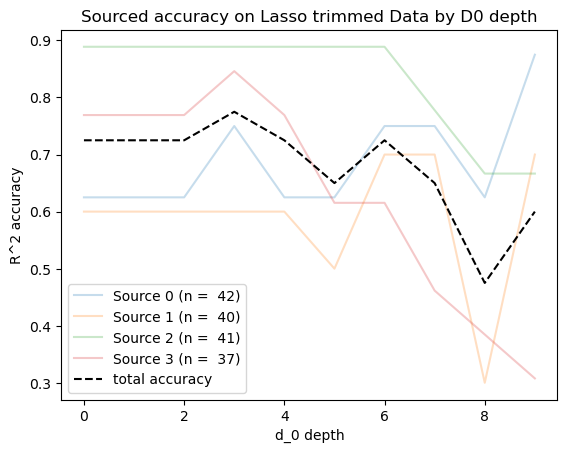

In [43]:
depth = np.arange(10)

#Source Accuracy
for i in range(len(source_score[0])):
    plt.plot(depth, source_score[:,i], label = f"Source {i} (n =  {source_size[i]})", alpha = 0.25)

plt.plot(depth, accuracy_score, color = 'black', linestyle = "dashed", label = "total accuracy")
plt.xlabel('d_0 depth')
plt.ylabel('R^2 accuracy')
plt.legend()
#plt.ylim(0,1)
plt.title("Sourced accuracy on Lasso trimmed Data by D0 depth")

In [44]:
def forest_wrapper(n_estimators, seed, depth):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=X[:,-1])
    mask = X_test[:,-1] == 3
    #print(f"Seed {seed}: Source 3 test indices = {np.where(mask)[0][:5]}")
    
    accuracy_score = []
    rf = []
    source_score = []

    for i in range(depth):
        #print("forest", i)
        temp_accuracy_score, temp_rf, temp_source_score, source_size  = forest(i, n_estimators)
        accuracy_score.append(temp_accuracy_score)
        rf.append(temp_rf)
        source_score.append(temp_source_score)
        preds = temp_rf.predict(X_test[mask])
         
        #print(f"Depth {i} Seed {seed}: preds={preds}, true={y_test[mask]}")
    
    source_score = np.array(source_score)
    

    return accuracy_score, rf, source_score, source_size

In [45]:
forests = [] # forest[0] is forests with same dataset
accuracy_score = []
source_score = [] #[seed,depth,source]
source_size = []

for i in range(10):
    temp_accuracy_score, rf, temp_source_score, temp_source_size = forest_wrapper(200, seed = i, depth = 20)
    forests.append(rf)
    accuracy_score.append(temp_accuracy_score)
    source_score.append(temp_source_score)
    source_size.append(temp_source_size)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
3
1
1
1
1
1
1
1
4
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
5
1
1
1
2
1
1
1
1
3
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
1
1
1
3
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
4
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
2
2
2
2
4
2
2
2
2
2
3
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
4
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2


Text(0, 0.5, 'Accuracy (R^2)')

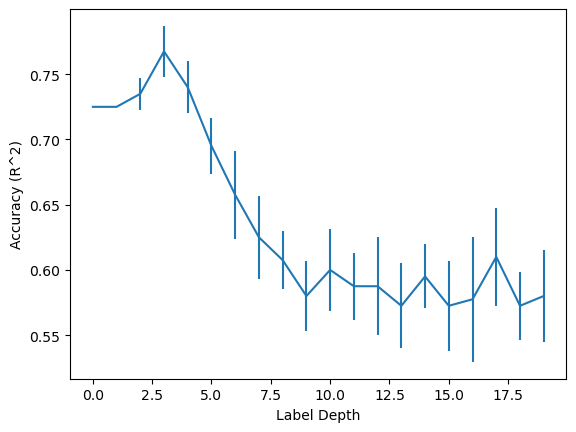

In [46]:
accuracy_mean = np.mean(accuracy_score, axis=0)  # shape: (n_depths,)
accuracy_std  = np.std(accuracy_score, axis=0)   # shape: (n_depths,)


depth = np.arange(20)
plt.errorbar(depth, accuracy_mean, yerr = accuracy_std)
plt.xlabel('Label Depth')
plt.ylabel('Accuracy (R^2)')